In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [129]:
df = pd.read_csv('website_traffic_2025_dataset.csv')

In [130]:
df.shape

(365, 5)

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         365 non-null    str    
 1   Sessions     365 non-null    int64  
 2   Bounce_Rate  365 non-null    float64
 3   Pages        365 non-null    float64
 4   Visitors     365 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 14.4 KB


In [132]:
df.describe()

,Sessions,Bounce_Rate,Pages,Visitors
count,365.000000,365.000000,365.000000,365.000000
mean,708.550685,48.362548,4.362767,604.810959
std,282.014108,10.519602,1.122588,245.350097
min,201.000000,30.180000,2.520000,151.000000
25%,467.000000,39.830000,3.340000,404.000000
50%,705.000000,49.380000,4.290000,609.000000
75%,948.000000,57.710000,5.280000,803.000000
max,1196.000000,64.990000,6.490000,1086.000000


In [133]:
df.isnull().sum()

Date           0
Sessions       0
Bounce_Rate    0
Pages          0
Visitors       0
dtype: int64

In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
df.dtypes

Date               str
Sessions         int64
Bounce_Rate    float64
Pages          float64
Visitors         int64
dtype: object

In [136]:
df['Date'] = pd.to_datetime(df['Date'])

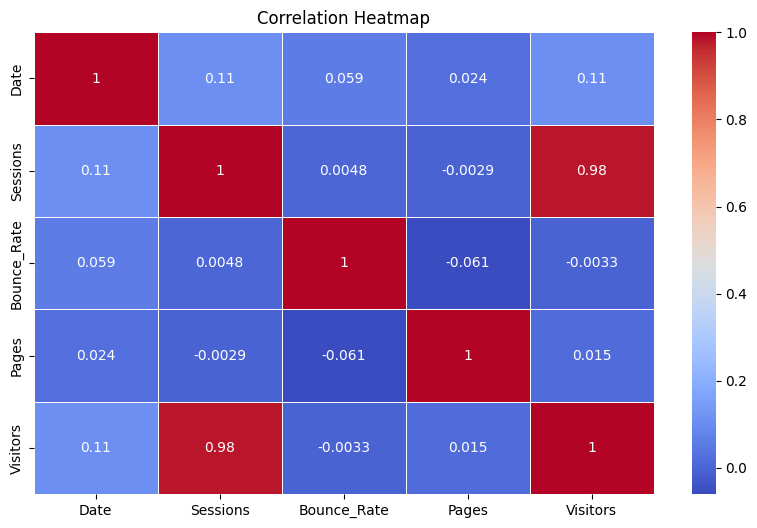

In [137]:
# Visualize the data by using heatmap to check the correlation between the features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

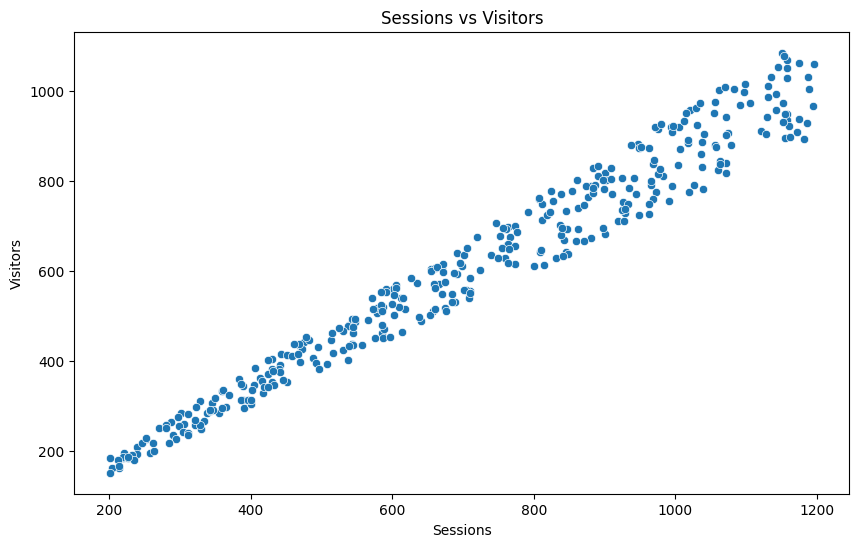

In [138]:
# Visualize the data by using scatter plot to check the relationship between the features
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sessions', y='Visitors', data=df)
plt.title('Sessions vs Visitors')
plt.xlabel('Sessions')
plt.ylabel('Visitors')
plt.show()

In [139]:
# intialising the x and y variables
x = df[['Sessions']]
y = df['Visitors']

In [140]:
# splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [157]:
# fitting the linear regression model
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


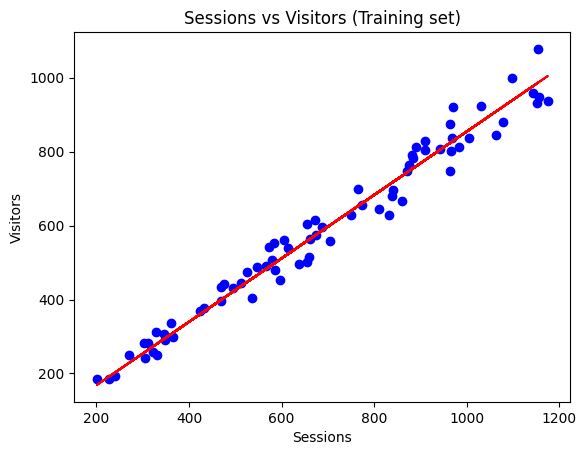

In [148]:
# Visualising Liner Regression results
plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test, lr.predict(x_test), color = 'red')
plt.title('Sessions vs Visitors (Training set)')
plt.xlabel('Sessions')
plt.ylabel('Visitors')
plt.show()


In [149]:
# Applying polynomial features 
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [150]:
# Training the polynomial regression model
lr_poly = LinearRegression()
lr_poly.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [151]:
y_pred_poly = lr_poly.predict(x_test_poly)
y_pred_poly.shape

(73,)

In [152]:
# check model accuracy
mse = mean_squared_error(y_test, y_pred_poly)
r2 = r2_score(y_test, y_pred_poly)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')


Mean Squared Error: 1525.75459654607
R^2 Score: 0.9712702758821057


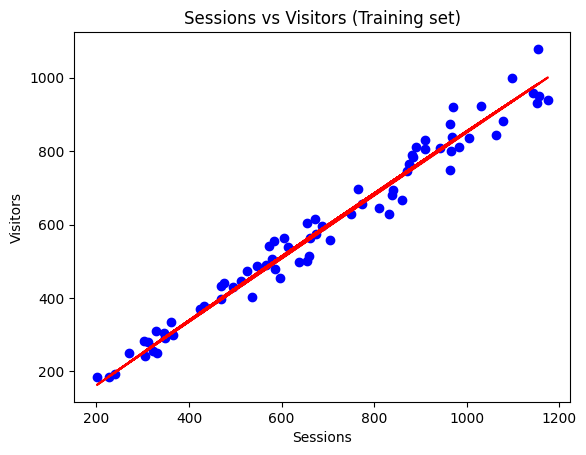

In [154]:
# Visualising Liner Regression results
plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test,y_pred_poly, color = 'red')
plt.title('Sessions vs Visitors (Training set)')
plt.xlabel('Sessions')
plt.ylabel('Visitors')
plt.show()